review on Friday:
logistic regression=단층 퍼셉트론
- 가중치가 세밀하게 있으면 표현력이 강해진다(예측력이 좋아진다)
- 입력층 -> 출력층

다층 퍼셉트론 - DNN(Deep Neural Network)
- 입력층 / 은닉층 / 출력층 구부
- 단층 퍼셉트론보다 모델 파라미터가 더 많음 -> 훨씬 더 표현력이 좋음
- 활성화함수, 소프트맥스 -> 확률 산출하고 가장 높은 확률 선택
- 은닉층: 다단계 필터 역할, 비선형 활성화 함수(Sigmoid, ReLU, Tanh 등) 반드시 함께 사용해야 비선형 곡선이 만들어짐
- ReLu(max(z, 0)) 음수는 0, 양수는 그대로 통과
- 은닉층 활성화 함수: 비선형성 부여(복잡한 패턴 학습)
- 출력층 활성화 함수: 최종 계산된 점수를 문제 목적에 맞게 결과 해석(확률 변환 등) by Softmax, Sigmoid

quick notice
- Feature가 100개라도 $\rightarrow$ 정답이 True/False (2가지) $\rightarrow$ 이진 분류 (출력층: Sigmoid)
- Feature가 3개라도 $\rightarrow$ 정답이 강아지/고양이/토끼 (3가지) $\rightarrow$ 다중 분류 (출력층: Softmax)

드롭아웃 기법(0.2 ~0.5 로 보통 설정)
- 일정비율의 출력을 랜덤하게 0으로 변경
- 가중치 과적합 피하기 위함
- 영향력이 강한 가중치의 출력이 0 => 작은 가중치도 가중치가 올라간다
- 

신경망 학습의 4단계 순환 구조

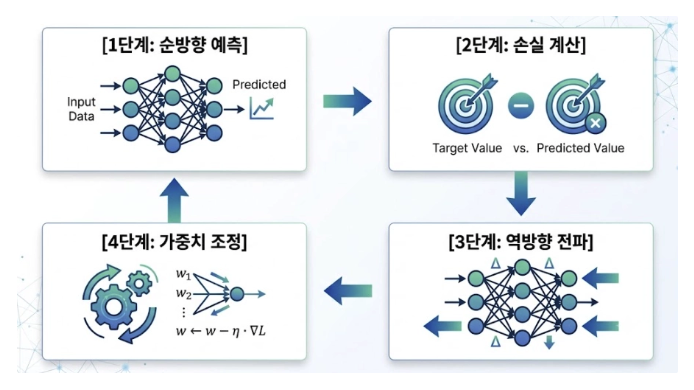


1단계 예측값 산출 -> 2단계 예측값 실제모델과 비교하여 Loss값 산출 -> 3단계 역전파 기울기 계산 -> 4단계 기울기 바탕으로 가중치 업데이트

*역전파 Backpropagation : Gradient 계산 -> 계산된 기울기를 optimizer 통해 가중치 업데이트 -> Epoch(학습 횟수)지정하여 학습 반복


optimizer : SGD, Momentum, Adam

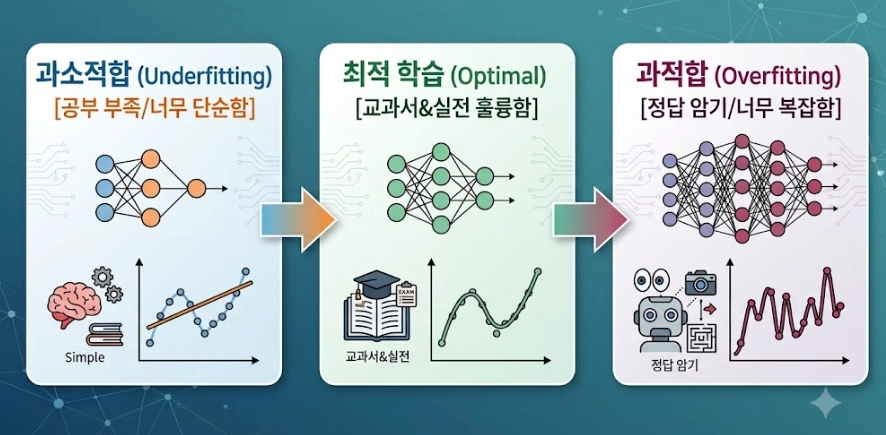

과소적합과 과적합 비교

## 4장 1강: 파이토치 기초 및 심층 신경망

### 6. 파이토치 기반 패션 이미지 다층 모델 실습
#### 6.1 데이터 준비 및 전처리
실습에 필요한 도구 불러오기 및 설정

In [69]:
# uv add torch torchvision
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor 
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# cuda=nvidia - mps - cpu 순으로 사용가능한 자원 체크 (GPU/MPS 사용하여 연산 빠르게)
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"현재 사용 중인 연산 디바이스: {device}") # OS에서 mps 출력

현재 사용 중인 연산 디바이스: mps


Fashion MNIST 데이터 불러오기

In [70]:
# 흑백 이미지, 28 X 28 (RGBA) (2차원) (0~255) -> 스케일링 필요 표준 점수 -> 특성은 1차원으로 변환 

# 총 데이터 = 60,000장 -> 훈련 데이터 50,000장 / 검증 데이터 10,000장
raw_train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=ToTensor() # data 폴더 만들기, train=True로 훈련데이터 세트 가져오기, download=True 없을 땐 다운로드, transform=totensor 파이토치로 변경
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor() #훈련일때만 True
)

PyTorch의 ToTensor()는 다음 두 가지 작업을 한 번에 자동으로 해줍니다:

- 이미지 데이터를 파이토치가 계산할 수 있는 텐서(Tensor) 형태로 변환합니다.

- 0~255 범위의 픽셀 정수값을 255로 알아서 나누어 0.0~1.0 사이의 실수값으로 스케일링해 줍니다.

In [71]:
# 검증 데이터셋 분리
train_size = 50000 #훈련데이터 50000장
val_size = 10000 #검증데이터 10000장

train_data, val_data = random_split(
    raw_train_data, [train_size, val_size], generator=torch.Generator().manual_seed(42) # []로 분리, manual_seed=seed값 설정-> 실행할 때마다 동일하게 분할하도록 설정
)

print("훈련 세트:", len(train_data))
print("검증 세트:", len(val_data))
print("테스트 세트:", len(test_data))

훈련 세트: 50000
검증 세트: 10000
테스트 세트: 10000


In [72]:
# 데이터 세트별 DataLoader 생성 -> 데이터 자르기(?)

# batch_size = 한 epoch에서 전체 데이터셋을 32개 배치로 분할한다 (조금씩 학습해야 안정적, 메모리 부족 문제 해결 -> 미니배치 경사하강법)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [73]:
# 28 x 28 
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 

### 6.2 모델 설계

다층 퍼셉트론(MLP) 모델 클래스 정의

In [74]:
import torch.nn as nn # torch nerual network [nn]
import torch.optim as optim

class AdvancedFashionClassifier(nn.Module): #pytorch module 정의시 Module highclass 받기

    # 사용할 층(layer)을 정의
    def __init__(self):
        super().__init__()

        # 차원수 28 x 28 -> 특성은 1차원으로 변경(784) (2차원 형태의 이미지 데이터를 1차원의 일렬 vector 데이터로 펼쳐주기 위함)
        # nn.Flatten()을 거치면 이미지 1장에 존재하는 784개의 픽셀이 하나의 독립된 입력데이터(x1, x2, ..., x784)가 되어 신경망에 공급됨
        # nn.Flatten() -> 2차원 Tensor -> 1차원 Tensor = 입력층
        self.flatten = nn.Flatten()

        # 은닉층 (784 -> 128)
        self.hidden_layer = nn.Linear(784, 128)

        # 은닉층에서 활성화 함수 ReLu 정의 -> 비선형성 주입하여 복잡한 데이터 패턴을 학습하게 만듦
        self.relu = nn.ReLU()

        # Dropout: 0~1, 0.1~0.5
        self.dropout= nn.Dropout(p=0.2) # 학습 중 뉴런의 20%를 무작위로 꺼서 특정 뉴런에 대한 과도한 의존성(과적합)을 방지

        # 출력층 128 -> 10개 분류 class로 압축
        self.output_layer = nn.Linear(128, 10) # FasionMNIST의 10개 의류 클래스별 예측점수(z-logit)을 출력


    # 순전파(Feed Forward)
    def forward(self, x):
        out = self.flatten(x) # 입력층 처리 28*28 -> 784
        out = self.hidden_layer(out) # 은닉층 784 -> 128
        out = self.relu(out) # 활성화 함수 통과(선형적 -> 비선형적)
        out = self.dropout(out) # 훈련시에만 필요, 과대적합 방지 (128,)
        out = self.output_layer(out) # 출력층 128 -> 10

        return out


모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당

In [75]:
# model instance 생성
model = AdvancedFashionClassifier().to(device) #to(device) 로 model도 계산할 수 있게 넘김

total_params= sum(p.numel() for p in model.parameters() if p.requires_grad) #?????????

print(f"학습 가능한 모델 파라미터 총 개수: {total_params:,}개")


학습 가능한 모델 파라미터 총 개수: 101,770개


손실 함수 및 옵티마이저 정의

In [76]:
# 손실함수
criterion = nn.CrossEntropyLoss() #기본 sparse하게 정의됨

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=0.005) #애매할때 Adam 쓰기, lr(learning rate)

#손실함수와 옵티마이저 항상 필수로 설정

### 6.3 조기 종료 학습 및 검증 루프

In [77]:
# 조기 종료
epochs = 20 # 최대 epoch
patience = 3 # 검증 loss가 더이상 떨어지지 않는 횟수, 3회 이상이면 학습 종료(조기종료)
patience_count = 0 
best_val_loss = float('inf') # 처음에는 가장 큰 것

# 손실값 모아주기
train_losses = []
val_losses = []

# 검증 루프
for epoch in range(epochs):
    running_loss = 0.0 # 한 에포크(각 배치의 모든 손실)의 손실 -- 배치?
    model.train() # 학습 모드 (학습에 필요한 것들 활성화 - ex) dropout 활성화)

    for images, labels in train_loader: #미니배치 (32개씩)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 이전 gradient 초기화 (다시 산출 위함)

        # 예측 - 현재 가중치 바탕으로
        outputs = model(images) # 순방향

        # loss 계산
        loss = criterion(outputs, labels)

        # 오차 역전파 수행 = gradient 계산 
        loss.backward()

        # optimizer = 가중치 업데이트
        optimizer.step()

        running_loss += loss.item() # batch마다의 loss를 기록 (1 epoch)

    epoch_loss = running_loss / len(train_loader) # 1 epoch당 loss (batch loss 의 평균)
    train_losses.append(epoch_loss)

    # 검증 모드
    model.eval() # 모델 평가시에는 학습시에만 필요한 부분이 배제됨 -> dropout 배제
    val_loss = 0.0

    with torch.no_grad(): # 검증시에는 gradient 연산 x, 학습 관련 연산을 하지 않음
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 검증세트 예측 (순전파)
            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | 훈련 loss: {epoch_loss:.4f} | 검증 loss: {val_loss:.4f}")

    # 조기 종료
    if epoch_val_loss < best_val_loss:
        # 기존 검증 로스보다 개선이 되었다!
        best_val_loss = epoch_val_loss
        patience_count = 0

            # 손실이 개선된 모델을 저장
        torch.save(model.state_dict(), "best_fashion_model.pth")

    else: # 기존 검증 로스보다 개선이 안되었다!
        patience_count += 1
        print(f"-- 검증 손실 미개선: {patience_count}/{patience}")

        # patience 한계를 초과하면 학습을 중단 (조기종료)
        if patience_count >= patience:
            print(f"조기 종료:{epoch+1} epoch에서 학습 종료")
            break


Epoch 1/20 | 훈련 loss: 0.5580 | 검증 loss: 137.6385
Epoch 2/20 | 훈련 loss: 0.4752 | 검증 loss: 125.6307
Epoch 3/20 | 훈련 loss: 0.4414 | 검증 loss: 126.5028
-- 검증 손실 미개선: 1/3
Epoch 4/20 | 훈련 loss: 0.4293 | 검증 loss: 124.4698
Epoch 5/20 | 훈련 loss: 0.4116 | 검증 loss: 125.2194
-- 검증 손실 미개선: 1/3
Epoch 6/20 | 훈련 loss: 0.3995 | 검증 loss: 131.2933
-- 검증 손실 미개선: 2/3
Epoch 7/20 | 훈련 loss: 0.4008 | 검증 loss: 122.5671
Epoch 8/20 | 훈련 loss: 0.3916 | 검증 loss: 124.8122
-- 검증 손실 미개선: 1/3
Epoch 9/20 | 훈련 loss: 0.3797 | 검증 loss: 123.7626
-- 검증 손실 미개선: 2/3
Epoch 10/20 | 훈련 loss: 0.3787 | 검증 loss: 131.8198
-- 검증 손실 미개선: 3/3
조기 종료:10 epoch에서 학습 종료


In [78]:
val_losses[:5]

[0.43973949796761186,
 0.4013759002279931,
 0.40416230915929563,
 0.3976669609070586,
 0.40006202266524776]

### 6.4 최종 테스트셋 기반 정확도 측정 및 시각화

predicted: tensor([9, 2, 1, 1, 0, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 2, 8, 0, 2, 7, 7, 9,
        1, 2, 6, 0, 9, 4, 8, 8], device='mps:0')
predicted: tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 3, 9, 6, 7, 2, 1, 4, 6, 2, 2, 5, 8, 2, 2,
        8, 4, 8, 0, 7, 7, 8, 5], device='mps:0')
predicted: tensor([1, 1, 6, 4, 7, 8, 7, 0, 2, 6, 4, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 2, 5, 3, 6, 7, 1, 8], device='mps:0')
predicted: tensor([0, 1, 4, 2, 3, 6, 7, 6, 7, 8, 5, 9, 9, 4, 2, 5, 7, 0, 5, 2, 8, 4, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 4], device='mps:0')
predicted: tensor([1, 5, 4, 1, 9, 1, 8, 4, 6, 1, 2, 5, 1, 0, 0, 0, 1, 2, 1, 3, 2, 2, 3, 2,
        1, 3, 5, 0, 4, 7, 9, 3], device='mps:0')
predicted: tensor([7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 0, 5, 4, 1, 2, 1, 3, 0, 9, 1, 0, 9, 3, 6,
        7, 9, 9, 4, 4, 7, 1, 2], device='mps:0')
predicted: tensor([1, 6, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 4, 8, 5, 4, 0], device='mps:0')
predicted: tensor([7

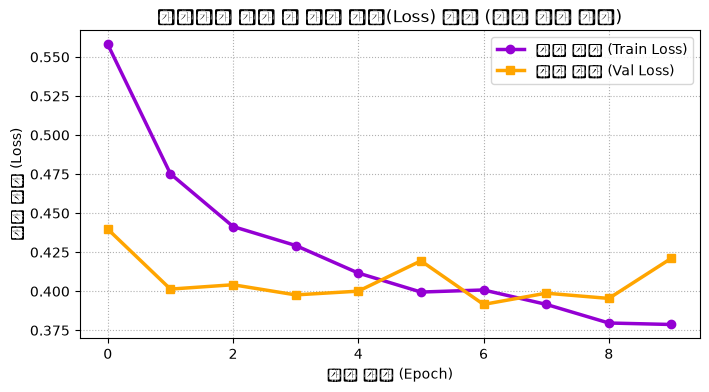

In [79]:
# 가장 좋은 가중치의 모델을 불러오기
model.load_state_dict(torch.load("best_fashion_model.pth"))
model.to(device)

# 테스트 셋으로 열기
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # True, False
        print("predicted:", predicted)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total * 100
print(f"테스트 세트 정확도: {test_accuracy:.3f}%")



# 3. 에포크별 훈련 및 검증 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='훈련 손실 (Train Loss)')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='검증 손실 (Val Loss)')
plt.title("에포크별 훈련 및 검증 손실(Loss) 추이 (조기 종료 적용)")
plt.xlabel("학습 횟수 (Epoch)")
plt.ylabel("손실 크기 (Loss)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()